# MODEL EVALUATION, METRICS, COMPARISION 

In this section, we **evaluate the performance of multiple deep learning models** trained for brain tumor classification.

The models compared are:
- **Custom CNN (baseline model)**
- **VGG16 (transfer learning)**
- **EfficientNetB0 (transfer learning)**
- **MobileNetV2 (lightweight model)**

The evaluation is based on:
- Accuracy
- Precision
- Recall (most important for this medical task)
- F1 Score
- ROC-AUC
- Confusion Matrix

Since this is a medical image classification problem, **recall (sensitivity)** is prioritized to minimize missed tumor cases.

In [1]:
import sys
print(sys.version)

3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]


In [2]:
!pip install tensorflow==2.21.0 torch torchvision torchaudio pandas matplotlib seaborn scikit-learn pillow ipykernel

ERROR: Could not find a version that satisfies the requirement tensorflow==2.21.0 (from versions: none)
ERROR: No matching distribution found for tensorflow==2.21.0


In [5]:
import os

for root, dirs, files in os.walk("."):
    for name in files:
        print(os.path.join(root, name))

.\04_evaluation_gradcam.ipynb
.\CapstoneProject (1).ipynb
.\CapstoneProject_Kavya_Custom_CNN_Only.ipynb
.\Evaluation and GRAD-CAM.ipynb
.\model_comparison.csv
.\model_comparison.json
.\model_comparison_partial.csv
.\plan.pdf
.\Untitled.ipynb
.\Untitled1.ipynb
.\.ipynb_checkpoints\04_evaluation_gradcam-checkpoint.ipynb
.\.ipynb_checkpoints\CapstoneProject (1)-checkpoint.ipynb
.\.ipynb_checkpoints\CapstoneProject_Kavya_Custom_CNN_Only-checkpoint.ipynb
.\.ipynb_checkpoints\Evaluation and GRAD-CAM-checkpoint.ipynb
.\.ipynb_checkpoints\Untitled-checkpoint.ipynb
.\.ipynb_checkpoints\Untitled1-checkpoint.ipynb
.\kavya_models\kavya_models\kavya_custom_cnn_best.keras
.\kavya_models\kavya_models\kavya_custom_cnn_final.keras
.\kavya_outputs\kavya_custom_cnn_confusion_matrix.png
.\kavya_outputs\kavya_custom_cnn_metrics_summary.csv
.\kavya_outputs\kavya_custom_cnn_roc_curve.png
.\kavya_outputs\kavya_custom_cnn_threshold_check.csv
.\kavya_outputs\kavya_custom_cnn_training_history.csv
.\kavya_outputs

In [6]:
import pandas as pd

cnn_df = pd.read_csv("./kavya_outputs/kavya_custom_cnn_metrics_summary.csv")
cnn_df

,model,threshold,test_accuracy,tumor_precision,tumor_recall_sensitivity,tumor_f1_score,roc_auc
0,Custom CNN,0.5,0.910029,0.88009,0.979849,0.927294,0.977016


In [7]:
cnn_metrics = {
    "Model": "Custom CNN",
    "Accuracy": cnn_df["test_accuracy"][0],
    "Precision": cnn_df["tumor_precision"][0],
    "Recall": cnn_df["tumor_recall_sensitivity"][0],
    "F1 Score": cnn_df["tumor_f1_score"][0],
    "ROC-AUC": cnn_df["roc_auc"][0]
}

cnn_metrics


{'Model': 'Custom CNN',
 'Accuracy': np.float64(0.9100294985250738),
 'Precision': np.float64(0.8800904977375565),
 'Recall': np.float64(0.9798488664987406),
 'F1 Score': np.float64(0.9272943980929678),
 'ROC-AUC': np.float64(0.9770162338535456)}

In [8]:
transfer_df = pd.read_csv("./model_comparison.csv")
transfer_df.head()

,model,best_epoch,training_minutes,best_threshold_from_val,val_loss,val_accuracy_0_50,val_recall_tumor_0_50,val_f1_tumor_0_50,val_accuracy_tuned,val_precision_tumor_tuned,...,test_loss,test_accuracy,test_precision_tumor,test_recall_tumor,test_f1_tumor,test_roc_auc_tumor,test_selection_score,confusion_matrix,checkpoint_path,classification_report_path
0,vgg16,4,47.018352,0.18,0.199007,0.927622,0.897222,0.929496,0.924668,0.901299,...,0.222058,0.915929,0.904762,0.957179,0.930233,0.975681,0.941560,"[[380, 17], [40, 241]]",C:\Users\purti.balani\Downloads\CAPSTONE\model...,C:\Users\purti.balani\Downloads\CAPSTONE\outpu...
1,efficientnet_b0,4,14.825387,0.21,0.223415,0.909897,0.886111,0.912732,0.911374,0.873134,...,0.216891,0.914454,0.887872,0.977330,0.930456,0.976102,0.951493,"[[388, 9], [49, 232]]",C:\Users\purti.balani\Downloads\CAPSTONE\model...,C:\Users\purti.balani\Downloads\CAPSTONE\outpu...
2,mobilenet_v2,1,9.623718,0.37,0.389619,0.847858,0.927778,0.866407,0.793205,0.729167,...,0.363349,0.803835,0.757812,0.977330,0.853685,0.943123,0.908030,"[[388, 9], [124, 157]]",C:\Users\purti.balani\Downloads\CAPSTONE\model...,C:\Users\purti.balani\Downloads\CAPSTONE\outpu...


In [9]:
transfer_df = transfer_df[[
    "model",
    "test_accuracy",
    "test_precision_tumor",
    "test_recall_tumor",
    "test_f1_tumor",
    "test_roc_auc_tumor"
]]

transfer_df.columns = ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

transfer_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,vgg16,0.915929,0.904762,0.957179,0.930233,0.975681
1,efficientnet_b0,0.914454,0.887872,0.977330,0.930456,0.976102
2,mobilenet_v2,0.803835,0.757812,0.977330,0.853685,0.943123


### MODEL COMPARISON

We create a comparison table using evaluation metrics from all models.
This helps in selecting the best model based on performance.

In [10]:
final_df = pd.concat([
    pd.DataFrame([cnn_metrics]),
    transfer_df
], ignore_index=True)

final_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Custom CNN,0.910029,0.880090,0.979849,0.927294,0.977016
1,vgg16,0.915929,0.904762,0.957179,0.930233,0.975681
2,efficientnet_b0,0.914454,0.887872,0.977330,0.930456,0.976102
3,mobilenet_v2,0.803835,0.757812,0.977330,0.853685,0.943123


#### INTERPRETATION:

From the comparison:

- Custom CNN:
  Recall = 0.9798 → highest among all models
  This means it almost never misses tumor cases.

- VGG16:
  Accuracy = 0.9159 and F1 Score = 0.9302 → best overall balance
  Performs consistently across all metrics.

- EfficientNetB0:
  Recall = 0.9773 (very high) and F1 Score ≈ VGG16
  Slightly lower accuracy than VGG16.

- MobileNetV2:
  Accuracy = 0.8038 (lowest)
  Although recall is high, precision is low → too many false positives.

Conclusion:
- Custom CNN and EfficientNet are strongest in tumor detection (recall)
- VGG16 provides the best balance between recall, precision, and accuracy
- MobileNet is less reliable due to lower overall performance

In [13]:
#Comparision table
final_df.to_csv("final_model_comparison.csv", index=False)

#### CONFUSION MATRIX

Confusion matrices are used to analyze prediction errors in detail for each model.
They show how many cases were correctly and incorrectly classified.


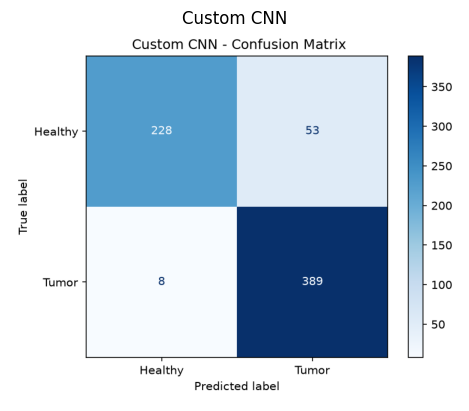

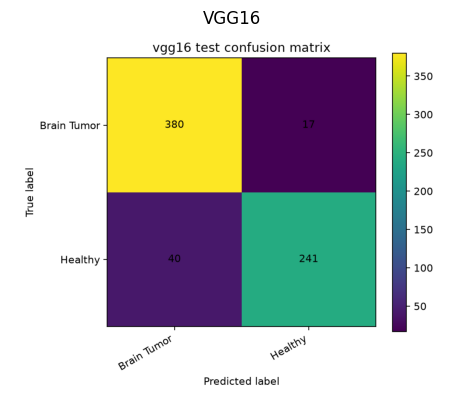

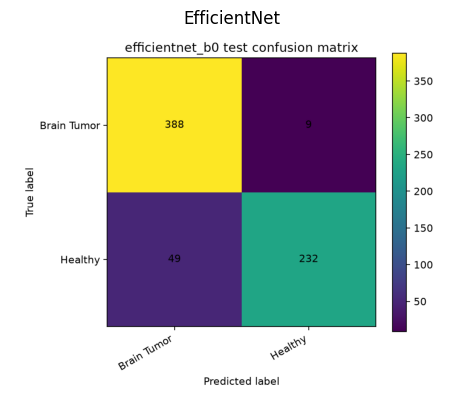

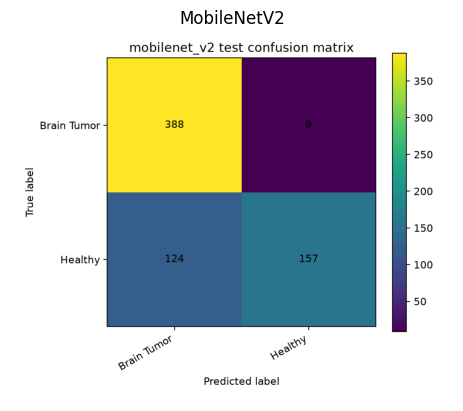

In [15]:
#Display all matrices
from PIL import Image
import matplotlib.pyplot as plt

def show_image(path, title):
    img = Image.open(path)
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

# Custom CNN
show_image("./kavya_outputs/kavya_custom_cnn_confusion_matrix.png", "Custom CNN")

# Transfer models
show_image("./plots/vgg16_test_confusion_matrix.png", "VGG16")
show_image("./plots/efficientnet_b0_test_confusion_matrix.png", "EfficientNet")
show_image("./plots/mobilenet_v2_test_confusion_matrix.png", "MobileNetV2")

#### MODEL-WISE ANALYSIS:

- Custom CNN:
  Very low FN → excellent tumor detection
  Slightly higher FP → predicts tumor more aggressively

- VGG16:
  Balanced FP and FN
  Stable and consistent predictions

- EfficientNet:
  Very high TP (correct tumor detection)
  Slightly higher FP compared to VGG16

- MobileNet:
  High FP → over-predicts tumor
  Not reliable for deployment

Conclusion:
Models with lower FN (Custom CNN, EfficientNet) are safer,
but VGG16 provides the best balance overall.

#### MODEL EVALUATION

We select the best model based on overall evaluation metrics and error analysis.

FINAL INTERPRETATION:

- Custom CNN has highest recall → safest model
- EfficientNet also has very high recall with good F1
- VGG16 has highest accuracy + balanced metrics

Selected Model: VGG16

Reason:
- Strong recall (0.957)
- Highest accuracy (~0.916)
- Best balance between precision and recall
- Stable performance across all metrics

**This makes VGG16 more reliable for real-world deployment.**
